<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Cwiczenie_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
def simulate_rwm_variance(a, k=5000, m=1000):


    current_states = np.random.normal(0, 1, size=k)
    path_sums = np.zeros(k)
    accepted_moves = 0

    for _ in range(m):
        path_sums += current_states

        # Generujemy propozycje z U(X_n - a, X_n + a)
        proposals = current_states + np.random.uniform(-a, a, size=k)

        # Obliczamy logarytm prawdopodobieństwa akceptacji (dla stabilności numerycznej)
        # log(exp((x^2 - y^2)/2)) = (x^2 - y^2) / 2
        log_alpha = (current_states**2 - proposals**2) / 2.0

        # Losujemy U(0,1) i decydujemy o akceptacji
        log_u = np.log(np.random.rand(k))
        accept_mask = log_u < log_alpha

        # Wykonujemy skoki dla zaakceptowanych łańcuchów
        current_states[accept_mask] = proposals[accept_mask]
        accepted_moves += np.sum(accept_mask)

    # Obliczamy empiryczną wariancję asymptotyczną dla f(x) = x
    trajectory_means = path_sums / m
    empirical_var_as = m * np.var(trajectory_means, ddof=1)

    # Obliczamy średni wskaźnik akceptacji
    acceptance_rate = accepted_moves / (k * m)

    return empirical_var_as, acceptance_rate

# ==========================================
# Uruchomienie scenariuszy
# ==========================================
scenarios = [0.1, 1.0, 5.0, 10.0]
results = []

print("Symulacja algorytmu Metropolisa dla π = N(0,1)")
print("-" * 55)

start_time = time.time()
for a in scenarios:
    var_as, acc_rate = simulate_rwm_variance(a)
    results.append({
        "Parametr 'a'": a,
        "Akceptacja (%)": f"{acc_rate * 100:.1f}%",
        "σ²_as (Wariancja)": f"{var_as:.4f}"
    })

display(pd.DataFrame(results))
print(f"Gotowe w {(time.time() - start_time):.3f} sekundy.")

Symulacja algorytmu Metropolisa dla π = N(0,1)
-------------------------------------------------------


,Parametr 'a',Akceptacja (%),σ²_as (Wariancja)
0,0.1,98.0%,638.6687
1,1.0,80.4%,16.7324
2,5.0,31.8%,4.1981
3,10.0,16.0%,8.8792


Gotowe w 1.842 sekundy.


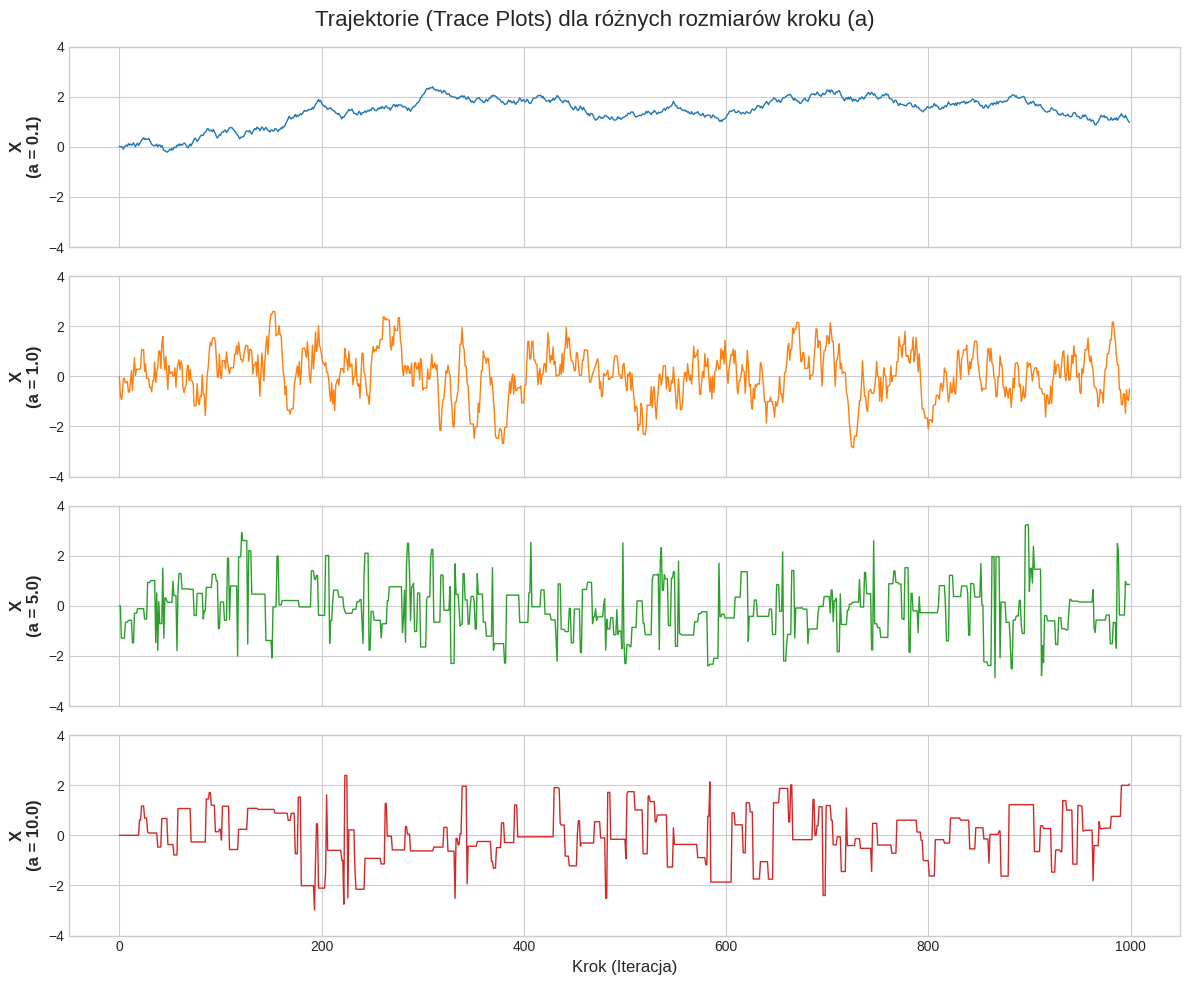

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_rwm_trajectory(a, m=1000):
    """Generuje jedną trajektorię o długości m dla podanego kroku a."""
    # Zaczynamy w zerze (środek rozkładu)
    current_state = 0.0
    trajectory = np.zeros(m)

    for i in range(m):
        # 1. Propozycja
        proposal = current_state + np.random.uniform(-a, a)

        # 2. Prawdopodobieństwo akceptacji (log dla stabilności)
        log_alpha = (current_state**2 - proposal**2) / 2.0

        # 3. Akceptacja lub odrzucenie
        if np.log(np.random.rand()) < log_alpha:
            current_state = proposal

        trajectory[i] = current_state

    return trajectory

# Ustawienia wykresu
scenarios = [0.1, 1.0, 5.0, 10.0]
m_steps = 1000

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Trajektorie (Trace Plots) dla różnych rozmiarów kroku (a)', fontsize=16)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, a, color in zip(axes, scenarios, colors):
    path = get_rwm_trajectory(a, m=m_steps)
    ax.plot(path, color=color, linewidth=1.0)
    ax.set_ylabel(f'X\n(a = {a})', fontsize=12, fontweight='bold')
    ax.set_ylim(-4, 4) # Sztywna oś Y dla łatwego porównania, bo N(0,1) rzadko wychodzi poza [-3, 3]

axes[-1].set_xlabel('Krok (Iteracja)', fontsize=12)
plt.tight_layout()
plt.show()